# Brief tutorial on reading the PlatoSim3 HDF5 output files

In [1]:
%matplotlib notebook

import matplotlib.pyplot as plt
import matplotlib.cm as cm

Set the environment and the Python PATH to the correct locations. Change the directories for projectDir and workDir to your personal locations.

In [2]:
import os, sys

#projectDir = "/Users/rik/Git/PlatoSim3/"
#workDir = "/Users/rik/Work/PLATO/"

projectDir = os.environ['PLATO_PROJECT_HOME'] #= projectDir
workDir = os.environ['PLATO_WORKDIR'] #= workDir

sys.path.append(projectDir + "/python")

In [3]:
import h5py
import h5
from h5 import h5get, h5ls

Run a default simulation with the input files as provided by the distribution.

In [4]:
import simulation
from simulation import Simulation

In [5]:
sim = Simulation('Run01', outputDir=workDir)
sim["PSF/Model"] = "MappedFromFile"
sim.run(removeOutputFile=True)

In [6]:
h5file = h5py.File(workDir + '/Run01.hdf5')

# h5ls

The function **h5ls** takes an HDF5 file object or a HDF5 group as a mandatory argument and shows the complete structure of the HDF5 file or group. Each level is indicated by the following type acronyms, and for attributes their value is shown.

[G] Group <br/>
[D] Dataset <br/>
[a] Attribute


In [7]:
h5ls(h5file['BiasMaps'])

[D] /biasMap000000
[D] /biasMap000001
    ...
[D] /biasMap000009


In [8]:
h5ls(h5file['InputParameters/CCD/Gain'])

[a] /     RefValueLeft      1.8
[a] /    RefValueRight      1.8
[a] /        Stability      -0.004
[a] /AllowedDifference      15.0


The full structure of the HDF5 file can be found at the end of this notebook, as it takes up too much space here.

# h5get

With **h5get** you can get data out of the HDF5 file into numpy arrays or python variables. This function takes two mandatory arguments, the HDF5 file object (or group) and the 'path into the variable or dataset'.

When you specify the full path, only that variable is returned as shown in the following two commands. When you specify a partial path or just the name of the final dataset/attribute, the **h5get** function looks for all possible matches and returns an array with their values. This is illustrated further with 'ReadoutNoise'.

In [9]:
pos = h5get(h5file, "/InputParameters/CCD/Position", verbose=False)
print ("Type and value of Position: {}, {}".format(type(pos), pos))

Type and value of Position: <class 'bytes'>, b'Custom'


In [10]:
noise = h5get(h5file, "/InputParameters/CCD/ReadoutNoise", verbose=False)
print ("Type and value of ReadoutNoise: {}, {}".format(type(noise), noise))

Type and value of ReadoutNoise: <class 'numpy.float64'>, 44.3


In [11]:
h5get(h5file, "ReadoutNoise")

selection strings: ['ReadoutNoise']
matching items:
    Attribute       /InputParameters/CCD/ReadoutNoise
    Attribute       /InputParameters/CCD/IncludeReadoutNoise
    Attribute       /InputParameters/FEE/ReadoutNoise
    Attribute       /InputParameters/RandomSeeds/ReadOutNoiseSeed


[44.299999999999997, 1, 40.5, 1424949740]

In [12]:
cols = h5get(h5file, "InputParameters/CCD/NumColumns", verbose=False)
print ("Type and value of NumColumns: {}, {}".format(type(cols), cols))

Type and value of NumColumns: <class 'numpy.int32'>, 4510


In [13]:
dec = h5get(h5file, "ACS/PlatformDec", verbose=False)
ra  = h5get(h5file, "ACS/PlatformRA", verbose=False)

In [14]:
print ("Type and shape of RA : {}, {}".format(type(ra), ra.shape))
print ("Type and shape of Dec: {}, {}".format(type(dec), dec.shape))

Type and shape of RA : <class 'numpy.ndarray'>, (10,)
Type and shape of Dec: <class 'numpy.ndarray'>, (10,)


In [15]:
im = h5get(h5file,"Images/image000000", verbose=False)

<IPython.core.display.Javascript object>


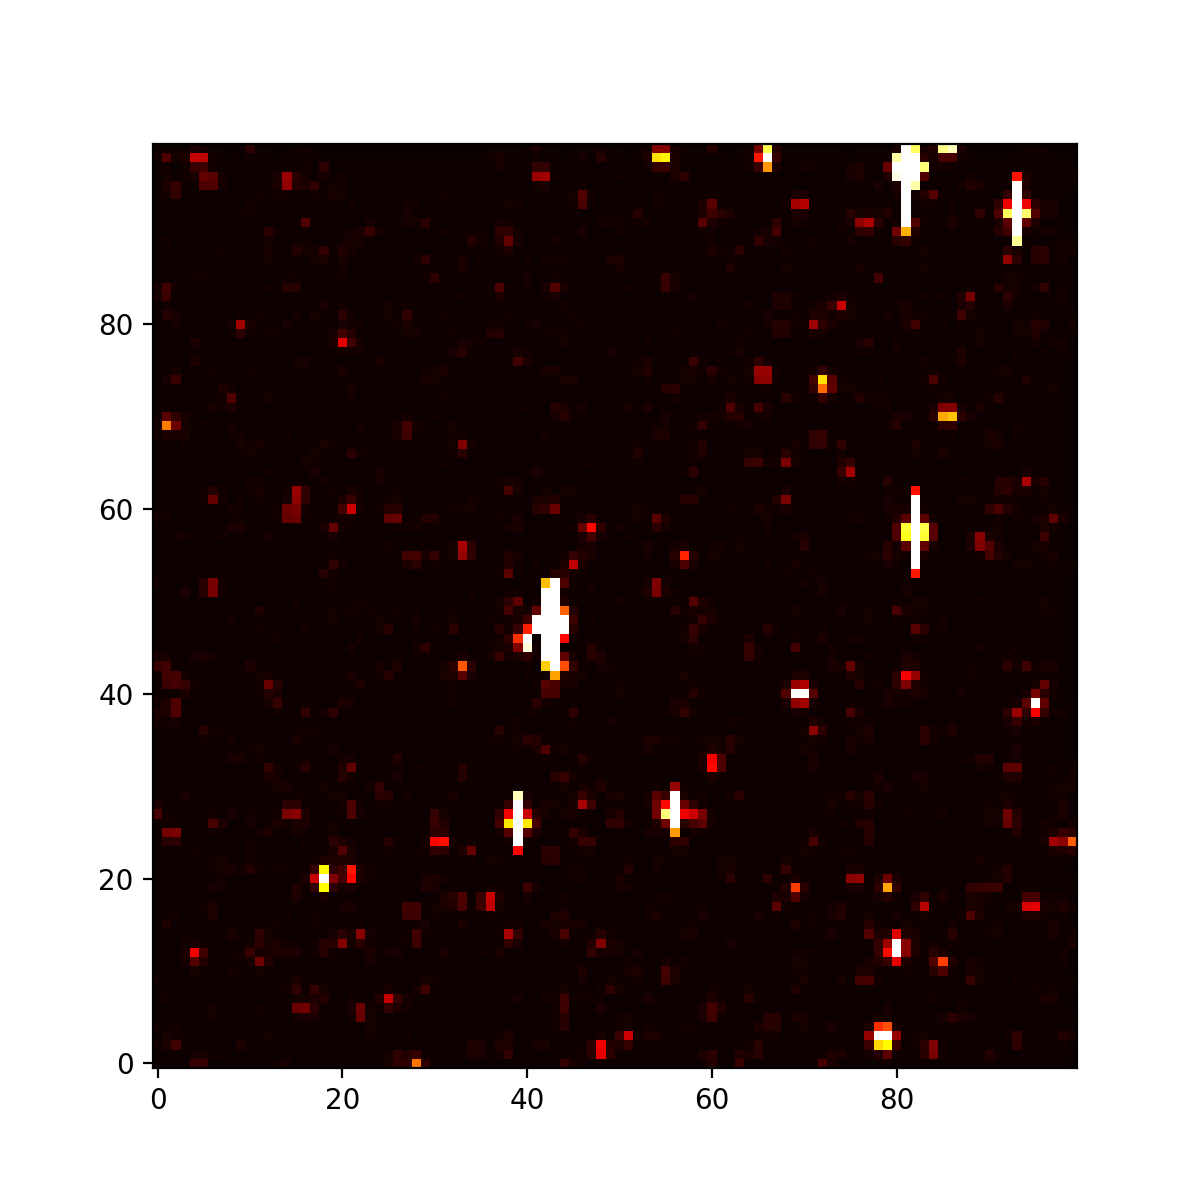

In [16]:
fig = plt.figure(figsize=(6, 6), dpi=100)

plt.imshow(im, cmap=cm.hot, interpolation="nearest", origin='lower')

In [17]:
h5ls(h5file)  # This is equivalent to specifying only the root group: h5ls(h5file['/'])

[G] /ACS
[D]     /Pitch
[D]     /PlatformDec
[D]     /PlatformRA
[D]     /Roll
[D]     /Time
[D]     /Yaw
[G] /Background
[D]     /skyBackground
[G] /BiasMaps
[D]     /biasMap000000
[D]     /biasMap000001
        ...
[D]     /biasMap000009
[G] /Flatfield
[D]     /IRNU
[D]     /PRNU
[G] /Images
[D]     /image000000
[D]     /image000001
        ...
[D]     /image000009
[G] /InputParameters
[G]     /CCD
[a]         /                       Position      b'Custom'
[a]         /                  OriginOffsetX      0.0
[a]         /                  OriginOffsetY      0.0
[a]         /                    Orientation      0.0
[a]         /                     NumColumns      4510
[a]         /                        NumRows      4510
[a]         /                FirstRowExposed      0
[a]         /                      PixelSize      18.0
[a]         /             FullWellSaturation      900000
[a]         /              DigitalSaturation      65535
[a]         /                   ReadoutNoise